# DWR Outlier Detection Tests + Machine-Learning Ready Dataset

Five groups across multiple state and federal organizations monitor water quality and quantity through a network of instruments located within water bodies across California. [Here](https://cdec.water.ca.gov/webgis/?appid=cdecstation) is a map of all the instruments (select sensor type: other).

Currently, all five organizations implement different pipelines to read, process, store, and serve the data. We propose to create a prototype machine-learning ready dataset that demonstrates a unified pipeline to create a consistent, reproducible, and easily accessible datataset. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime as dt_obj
from IPython.display import display
from scipy import stats
 
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 3000)

## Data processing

To process the data, we will implement standardized outlier detection methods as outlined in the [Outlier Detection Test Best Practices](https://docs.google.com/document/d/1YmXWDMHCKnWniQ4sMkkT5g5j5H5TmT3f/edit?usp=drive_link&ouid=112329730124000397523&rtpof=true&sd=true) guide. Group 3 includes suggested tests, which we can supplement with other ideas (e.g. [Talagala+2019](https://doi.org/10.1029/2019WR024906)). 

### Ingest sample data

In [2]:
def get_data_from_local_directory(filename, path):
    """
        Get data from a local directory.

        Parameters
        ----------
        filename : str
            Name of file to get from local directory.
        path : str
            Path to local directory.
        
        Returns
        -------
        df : pandas.DataFrame
            Dataframe containing data from local directory.
        
        Examples
        --------
        >>> get_data_from_local_directory('test.csv', 'data/')
    """
    file_with_path = path + filename
    df = pd.read_csv(file_with_path)
    
    return df

In [3]:
df = get_data_from_local_directory(filename='sample_data_BKS.csv', path='sample_data/')

In [4]:
df

,STATION_ID,DURATION,SENSOR_NUMBER,SENSOR_TYPE,DATE TIME,OBS DATE,VALUE,DATA_FLAG,UNITS
0,BKS,D,62,PH VAL,19890203 0000,19890203 0100,---,,PH
1,BKS,D,62,PH VAL,19890204 0000,19890204 0000,---,,PH
2,BKS,D,62,PH VAL,19890205 0000,19890205 0000,---,,PH
3,BKS,D,62,PH VAL,19890206 0000,19890206 0000,---,,PH
4,BKS,D,62,PH VAL,19890207 0000,19890207 0000,---,,PH
...,...,...,...,...,...,...,...,...,...
12914,BKS,D,62,PH VAL,20241207 0000,20241207 0000,7.4,,PH
12915,BKS,D,62,PH VAL,20241208 0000,20241208 0000,7.5,,PH
12916,BKS,D,62,PH VAL,20241209 0000,20241209 0000,7.5,,PH
12917,BKS,D,62,PH VAL,20241210 0000,20241210 0000,7.5,,PH


Convert all string values of '---' to `np.Nan`

In [5]:
df.replace(to_replace='---', value=np.nan, inplace=True)

Convert string values in `DATE TIME` column to datetime object, rename it `TIME`, and set it as the index.

In [6]:
df['TIME']=pd.to_datetime(df['DATE TIME'], format='%Y%m%d %H%M').reset_index(drop=True)

In [7]:
df = df.set_index('TIME')

Convert all string values of numbers to ints for the column `VALUE`

In [8]:
df.VALUE = pd.to_numeric(df.VALUE)

## Group 1 Tests

The following six tests comprise Group 1 of the [Outlier Detection Test Best Practices](https://docs.google.com/document/d/1YmXWDMHCKnWniQ4sMkkT5g5j5H5TmT3f/edit) document. 

### Time Gap test

The Time Gap test to see if there is a gap in the data based on an expected time frequency (e.g., 15 minutes, 1 hour, etc.).

The input variable `cadence` defines the nominal cadence of the time series. This test is less useful than preferred, because the sample data contains an entry for every time stamp at appropriate cadence, but includes `np.nan` for missing data. A more useful test is a value gap test (below).

In [9]:
def time_gap_test(df: pd.DataFrame, cadence: pd.Timedelta) -> pd.DataFrame:
    """
    Apply a time gap test.
    
    Parameters
    ----------
    df : pd.DataFrame
        A pandas series with a datetime index.

    cadence : pd.Timedelta
        The nominal cadence of the data.

    Returns
    -------
    pd.Series
        Outliers flagged as True or False.

    Examples
    --------
    >>> df_time_gap = time_gap_test(df, cadence=pd.Timedelta('1 days'))

    """
    if df.empty:
        raise ValueError('No input data.')
    if df.index.dtype != 'datetime64[ns]':
        raise ValueError('Input data is not a datetime index.')
    df['Time Gap Flag'] = np.where((df.index.diff() > cadence), True, False)
    return df

In [10]:
df_time_gap = time_gap_test(df=df, cadence=pd.Timedelta('1 days'))

<Axes: xlabel='TIME', ylabel='Time Gap Flag'>

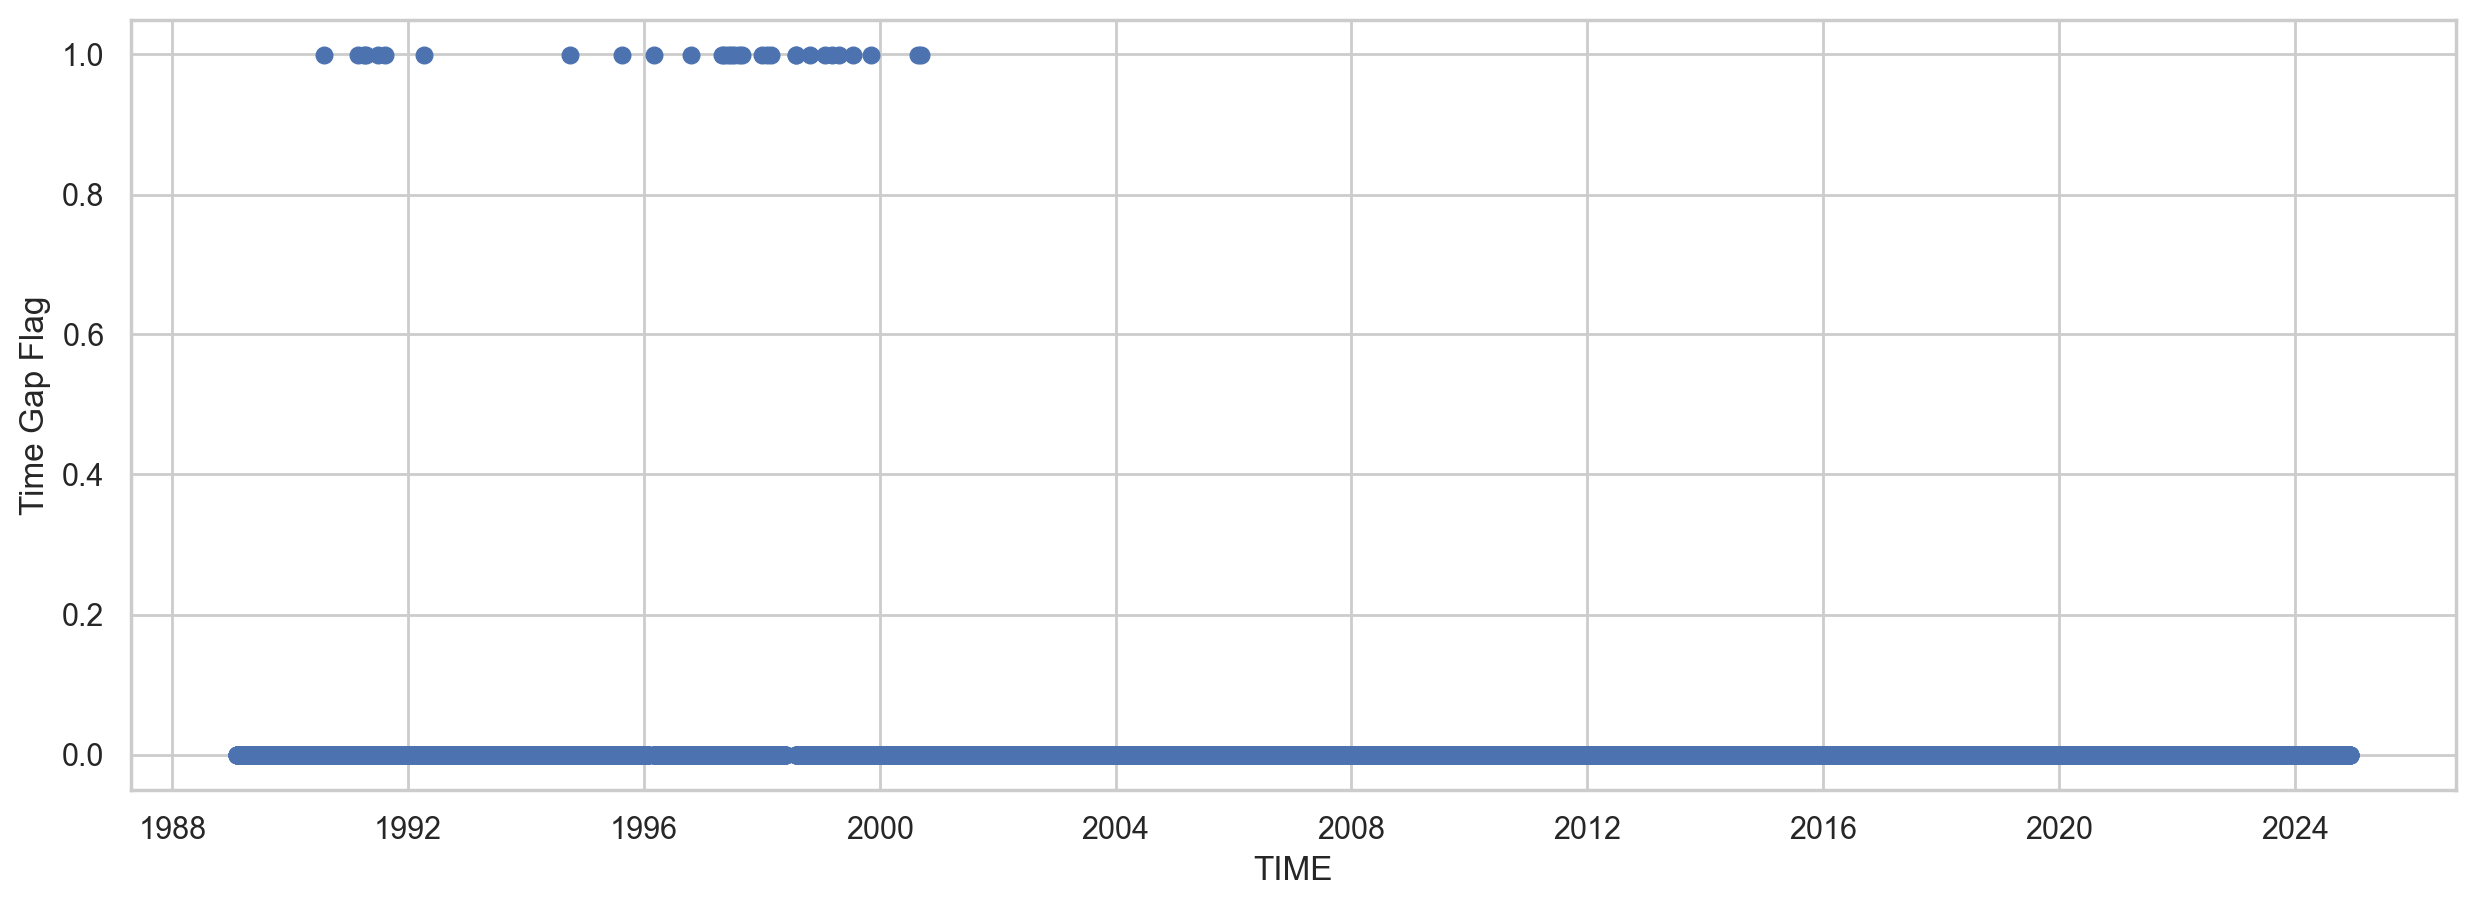

In [11]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_time_gap, x='TIME', y='Time Gap Flag', edgecolor=None)

In [12]:
def value_gap_test(time_series: pd.Series) -> pd.Series:
    """
    Apply a value gap test to a time series.
    
    Parameters
    ----------
    time_series : pd.Series
        A pandas series with a datetime index.

    Returns
    -------
    pd.Series
        Outliers flagged as True or False.

    Examples
    --------
    >>> df_value_gap = value_gap_test(df)

    """
    if time_series.empty:
        raise ValueError('No input data.')
    df['Value Gap Flag'] = np.where((time_series.isna() == True), False, True)
    return df

In [13]:
df_value_gap = value_gap_test(time_series=df.VALUE)

<Axes: xlabel='TIME', ylabel='Value Gap Flag'>

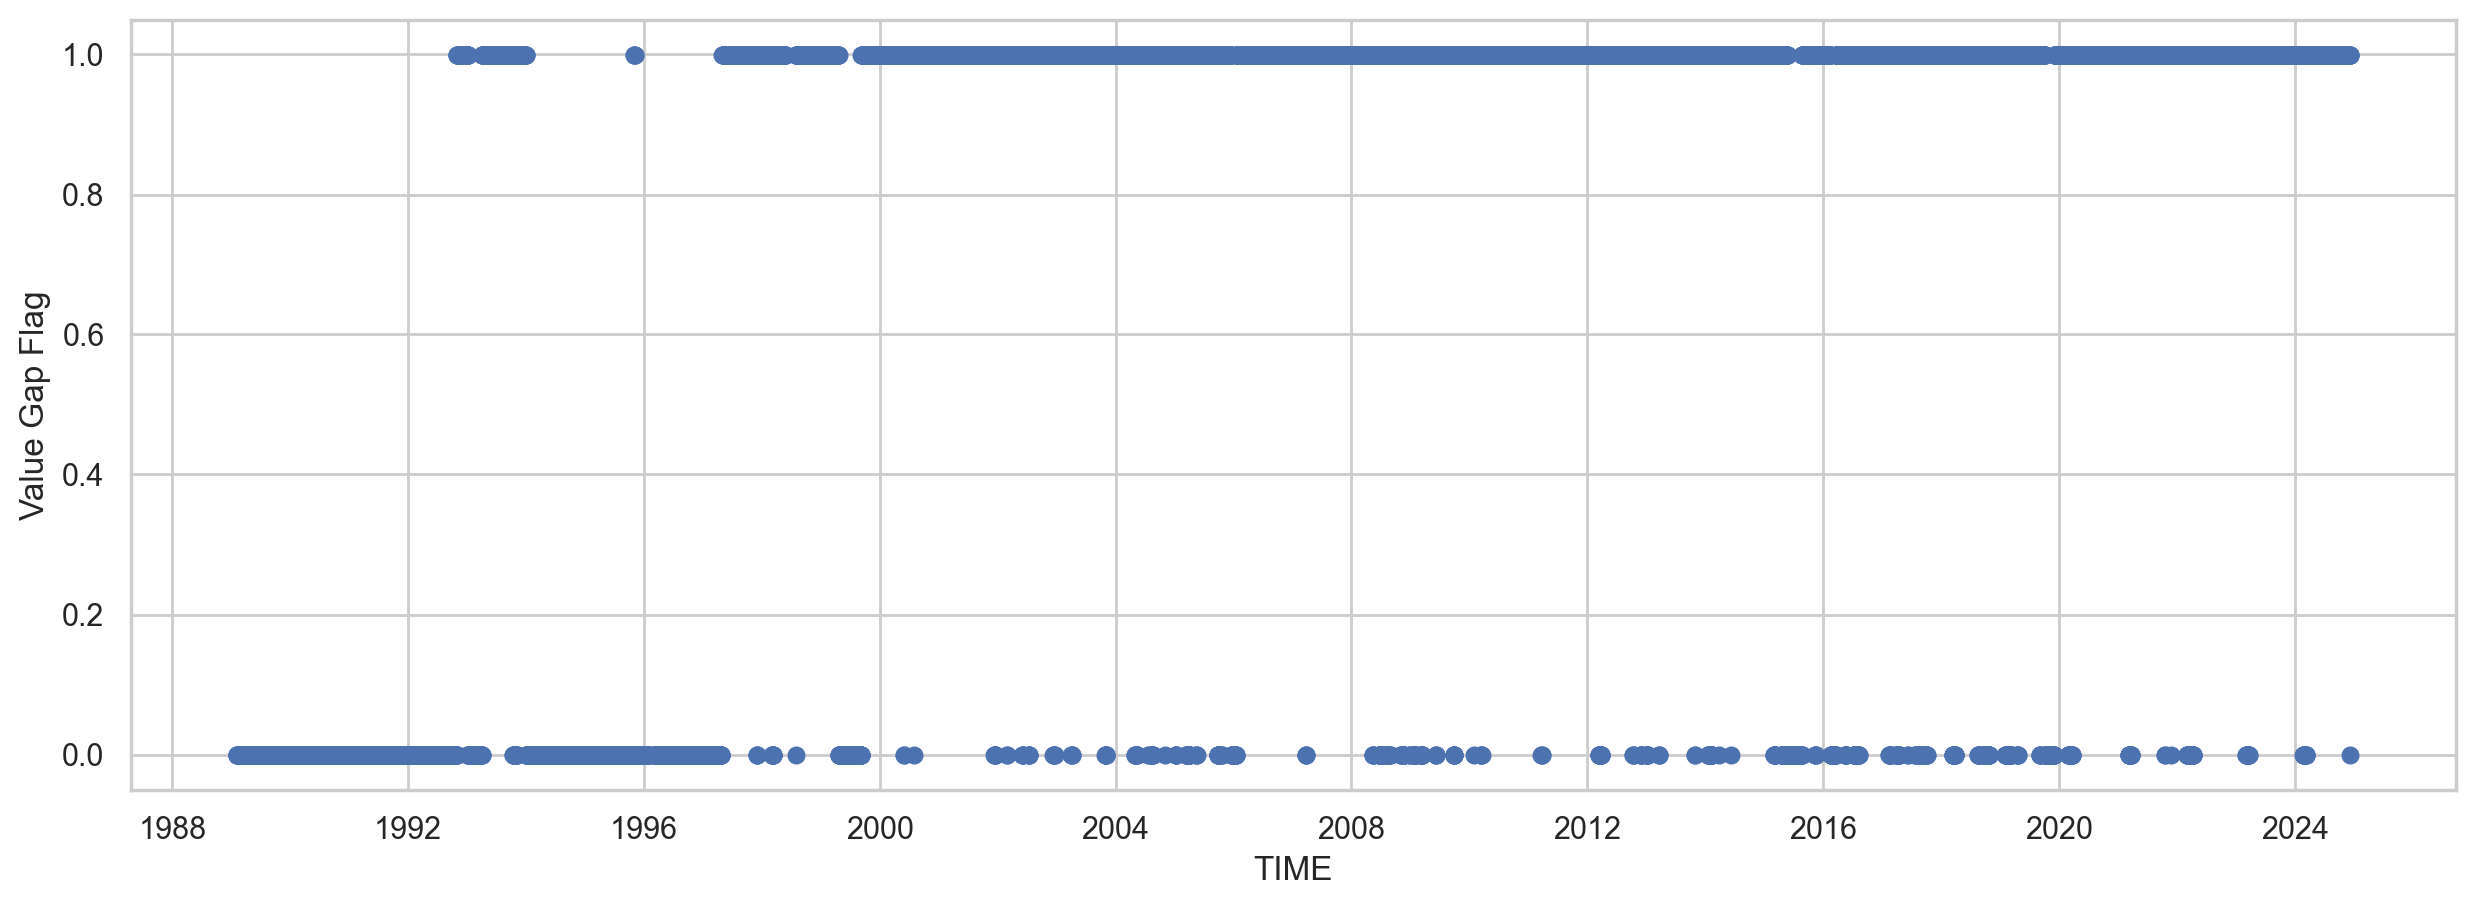

In [14]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_value_gap, x='TIME', y='Value Gap Flag', edgecolor=None)

### Basic and Tuned Gross range test

Basic Gross Range Test: Checks if data point exceeds sensor minimum or maximum values.*  
Tuned Gross Range Test: A variation on the Gross Range Test, where the thresholds are determined and adjusted by the operator on a monthly or seasonal basis, or some other predefined time period.

The input variable `bound` can define sensor maximum and minimum values or operator-determined thresholds. Therefore the gross range test below satisfies both tests (4) and (5) in Group 1 of the [Outlier Detection Test Best Practices](https://docs.google.com/document/d/1YmXWDMHCKnWniQ4sMkkT5g5j5H5TmT3f/edit) document.

In [15]:
def gross_range_test(time_series: pd.Series, bounds: tuple) -> pd.DataFrame:
    """
    Apply a gross range test to a time series.

    Parameters
    ----------
    time_series : pd.Series
        A pandas series with a datetime index.

    bounds : tuple
        The lower and upper bounds for the test.

    Returns
    -------
    pandas.DataFrame
        Outliers flagged as True or False.
    
    Examples
    --------
    >>> df_gross_range = gross_range_test(df_in, (0, 100))

    """
    df = pd.DataFrame(time_series.copy())
    if df.empty:
        raise ValueError('No input data.')
    if not all(bounds):
        raise ValueError('One of all of the bounds is empty.')
    df['Gross Range Flag'] = np.where(((df > bounds[1]) | ((df <= bounds[0]))), True, False) 
    return df

In [16]:
df_gross_range = gross_range_test(time_series=df.VALUE, bounds=[4,8])

<Axes: xlabel='TIME', ylabel='VALUE'>

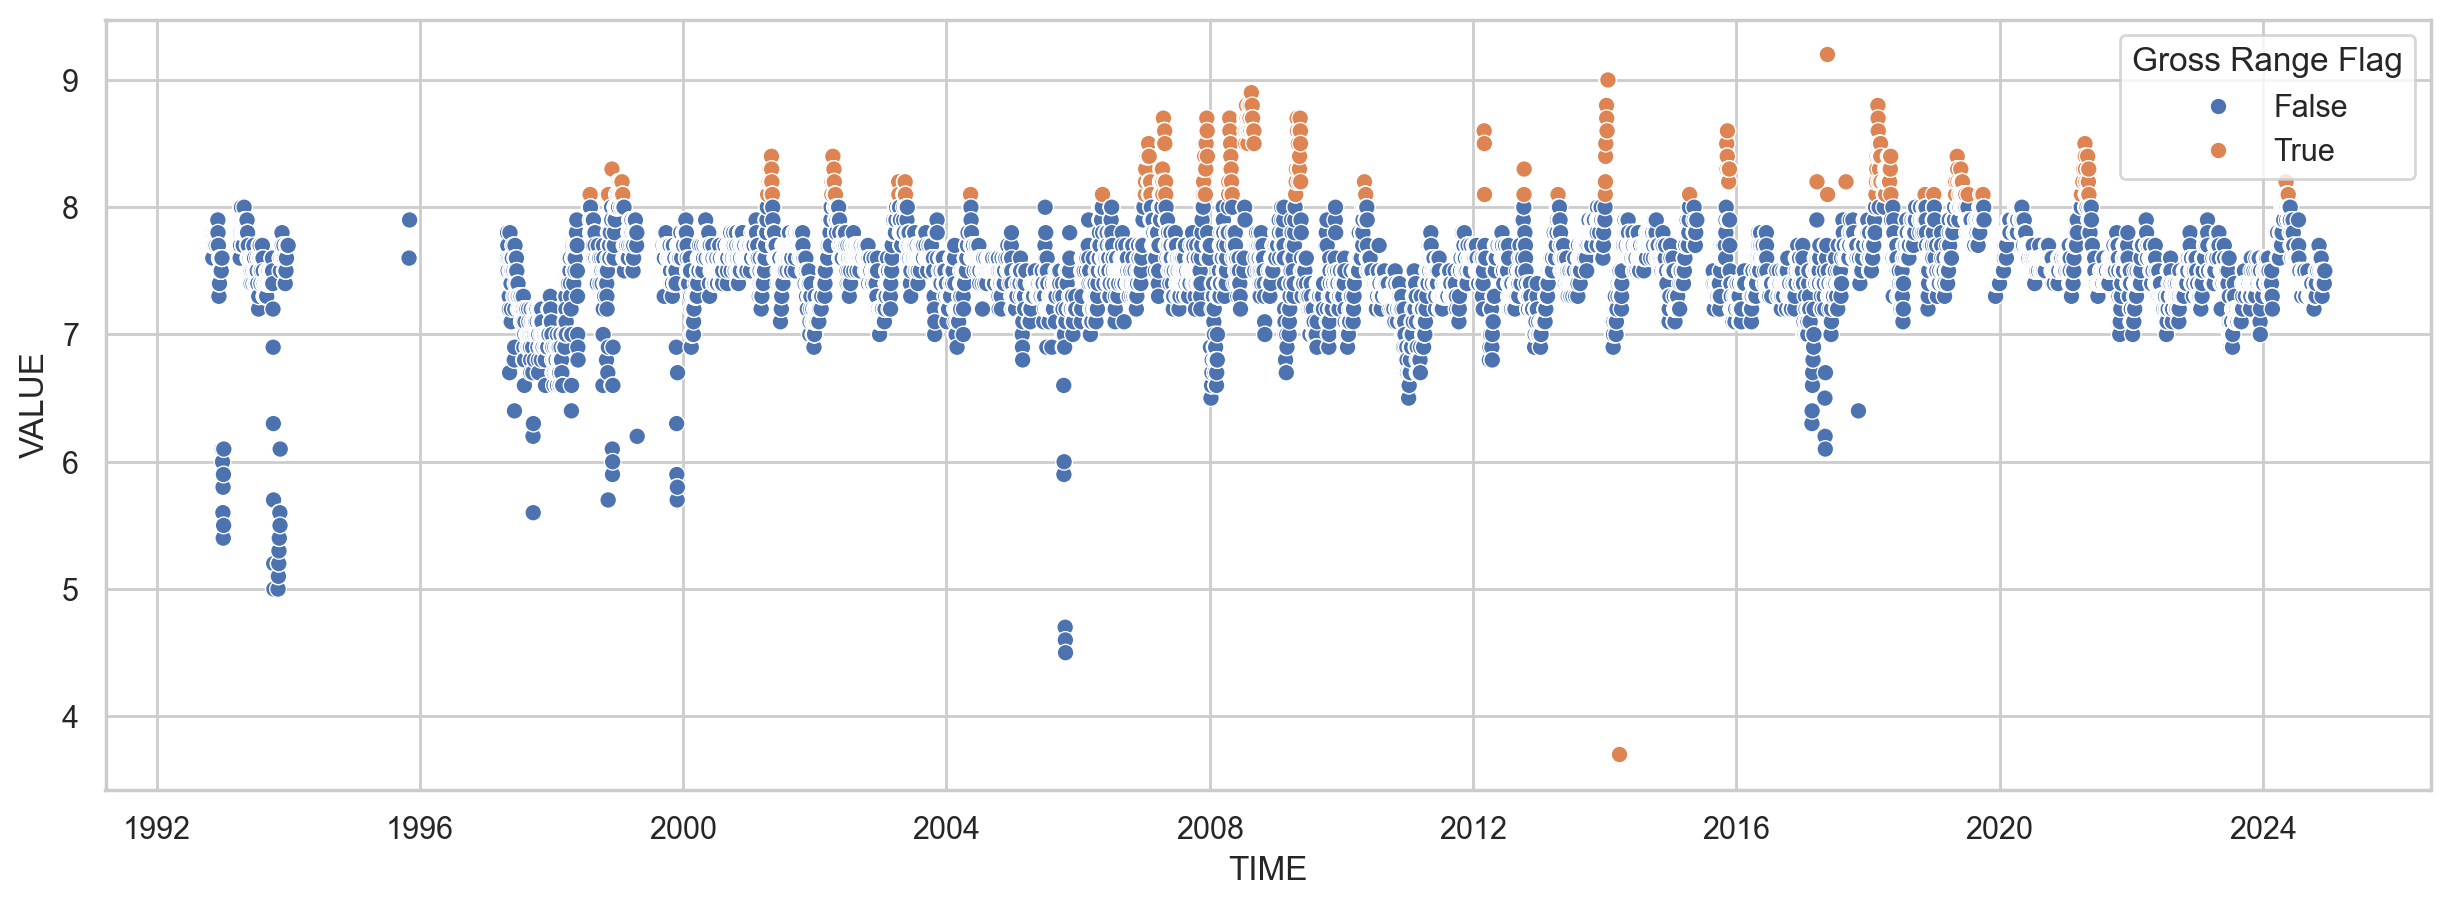

In [17]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_gross_range, x='TIME', y='VALUE', hue='Gross Range Flag')

### Flat line test

The flat line test compares the present observation to several previous observations to identify a continuously repeated observation of the same value, which is a common result when sensors and/or data collection platforms fail.

In [18]:
def flat_line_test(time_series: pd.Series, number_of_repeated_values: int = 1) -> pd.DataFrame:
    """
    Apply a flat line test to a time series.

    Parameters
    ----------
    time_series : pd.Series
        A pandas series with a datetime index.
    
    number_of_repeated_values : int
        The number of consecutive repeated values to indicate an instrumental anomaly.

    Returns
    -------
    pandas.DataFrame
        Outliers flagged as True or False.
    
    Examples
    --------
    >>> df_out = flat_line_test(df_in)

    """
    if time_series.empty:
        raise ValueError('No input data.')
    mask = time_series.ne(time_series.shift())
    counts = time_series.groupby(mask.cumsum()).transform('count')
    df['Flat Line Flag'] = np.where((counts > number_of_repeated_values ), True, False)
    return df

In [19]:
df_flat_line = flat_line_test(time_series=df.VALUE, number_of_repeated_values=5)

<Axes: xlabel='TIME', ylabel='VALUE'>

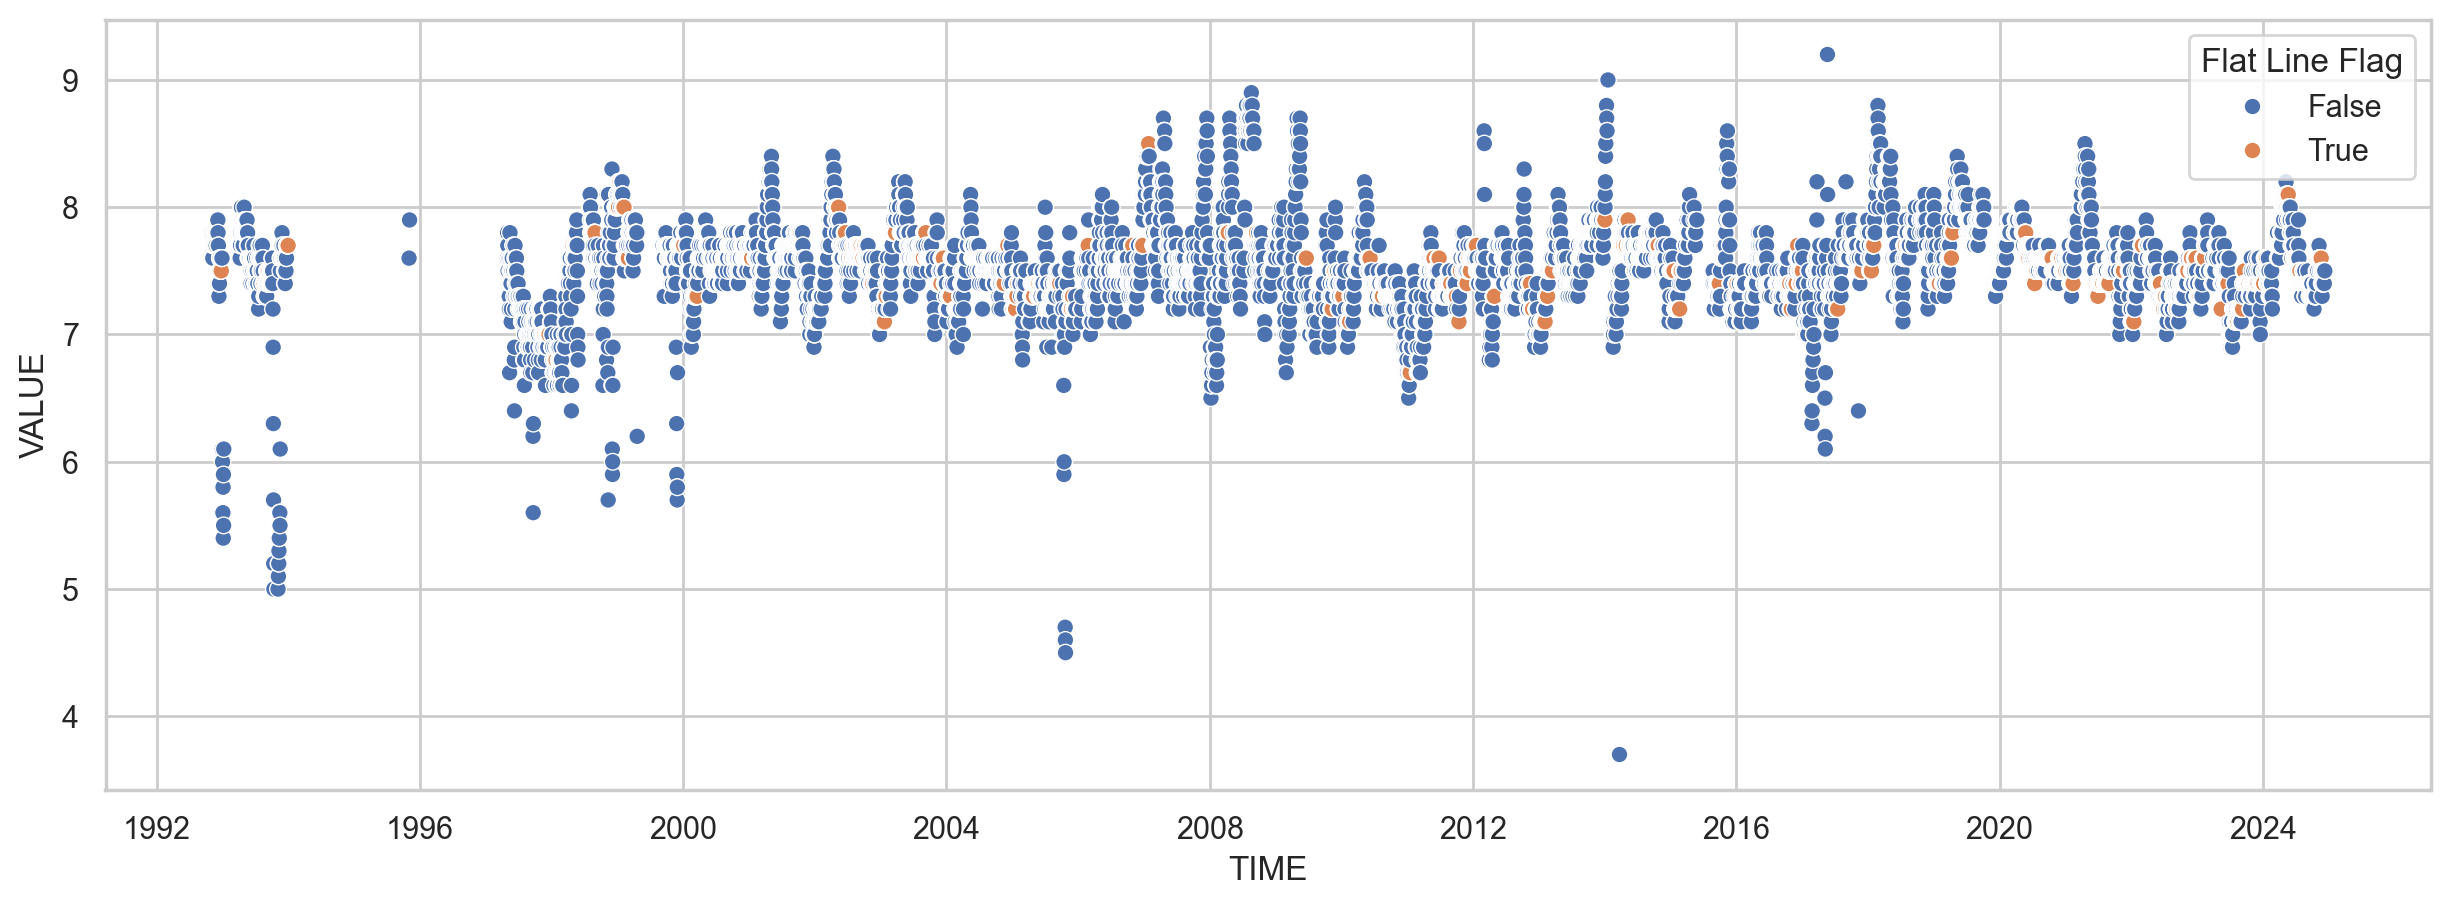

In [20]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_flat_line, x='TIME', y='VALUE', hue='Flat Line Flag')

Another possibility for display:

<Axes: xlabel='TIME', ylabel='Flat Line Flag'>

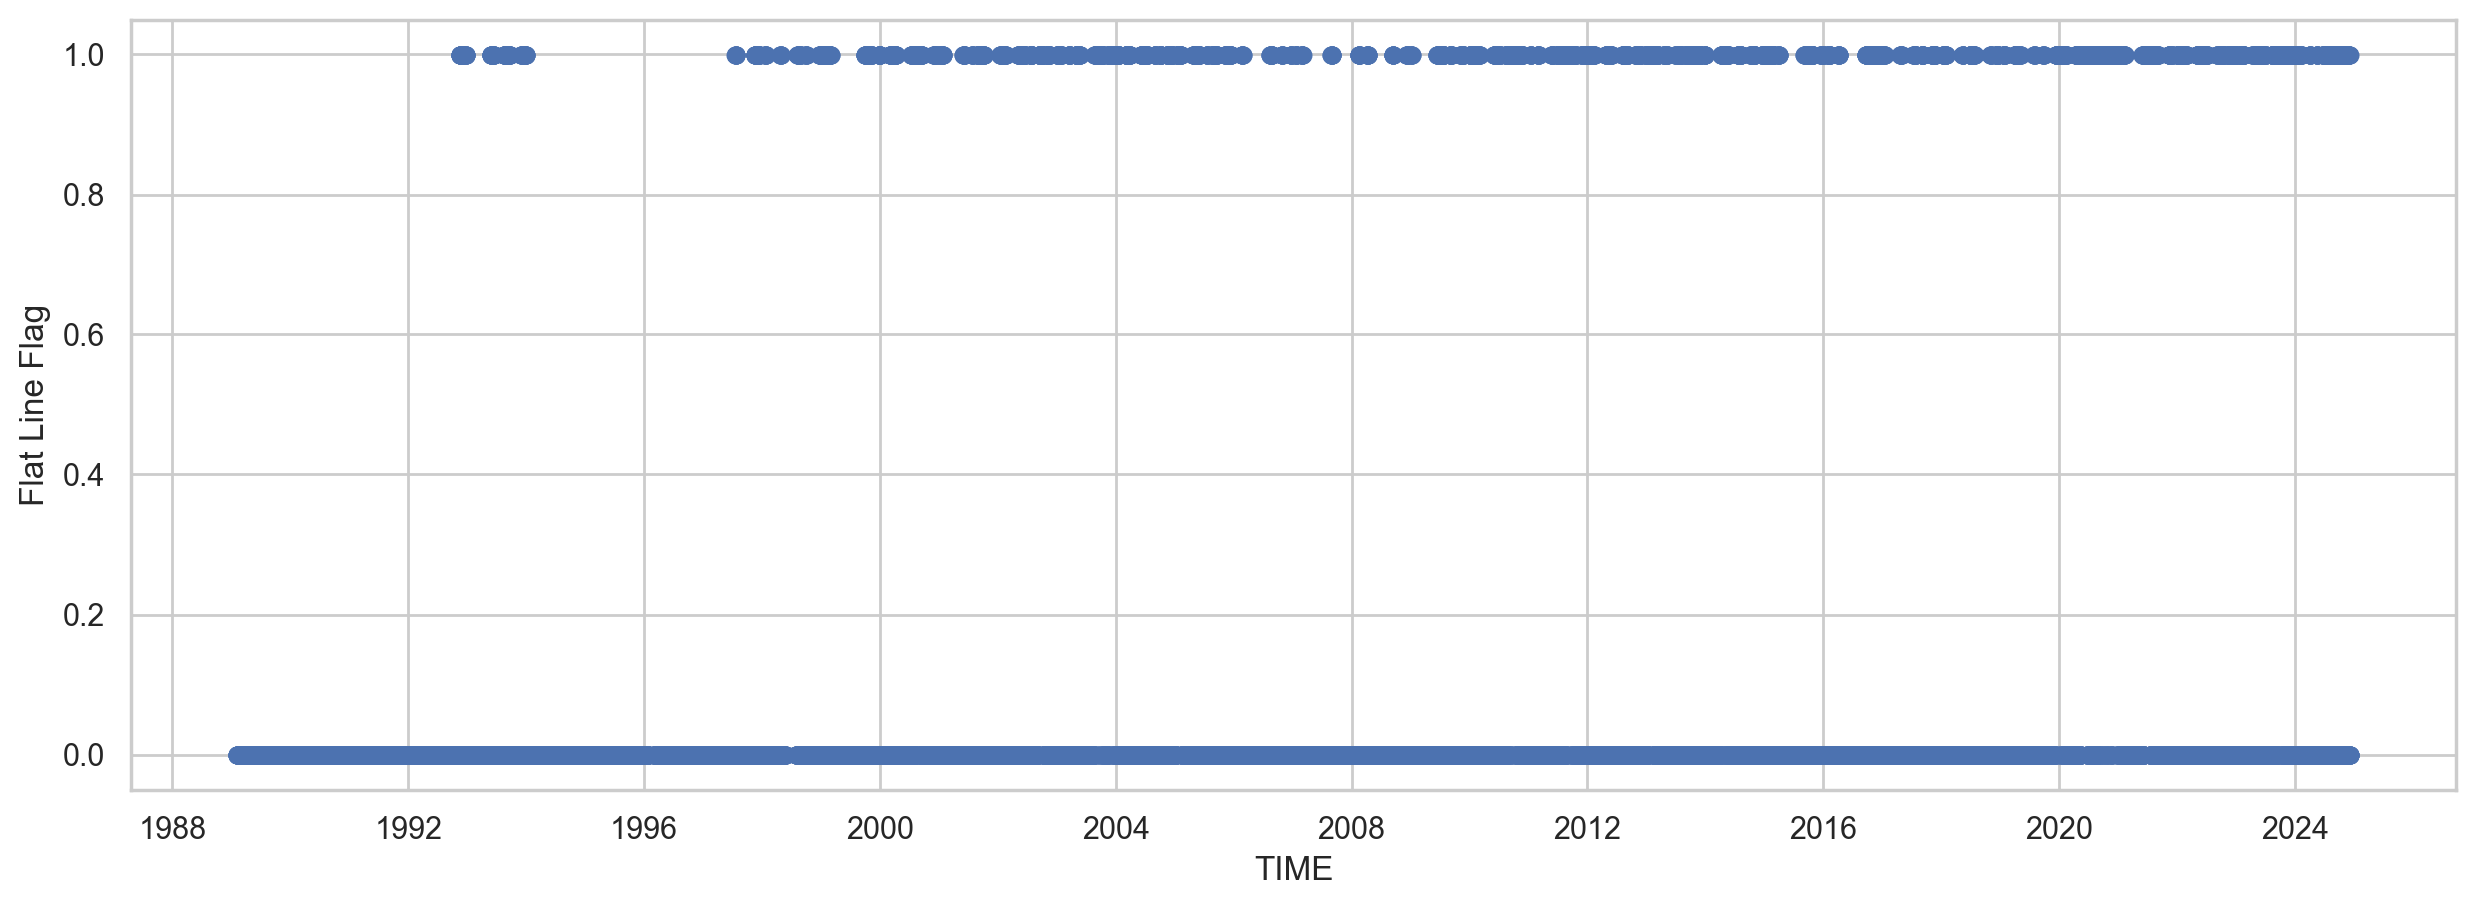

In [21]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_flat_line, x='TIME', y='Flat Line Flag', edgecolor=None)

## Group 2 Tests

The following six tests comprise Group 2 of the [Outlier Detection Test Best Practices](https://docs.google.com/document/d/1YmXWDMHCKnWniQ4sMkkT5g5j5H5TmT3f/edit) document. 

### Z-score and Modified Z-score tests

The Z-score calculates the number of standard deviations from the mean per point in the time series. Taken from Scipy; see [stats.zscore()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.html).

In [56]:
def z_score_test(time_series: pd.Series, number_of_standard_deviations: int=3) -> pd.DataFrame:
    """
    Apply the Scipy Z-Score test to a time series. Flag values based on the number of standard deviations from the mean.

    Parameters
    ----------
    time_series : pd.Series
        A pandas series with a datetime index.
    
    number_of_standard_deviations : int, optional
        The number of standard deviations from the mean to flag. Default is 3.

    Returns
    -------
    pandas.DataFrame
        Outliers flagged as True or False.
    
    Examples
    --------
    >>> df_out = z_score_test(time_series)

    """
    if time_series.empty:
        raise ValueError('No input data.')
    z_score = stats.zscore(time_series, nan_policy='omit')
    modified_z_score = (0.6745 * (time_series - time_series.median())) / (stats.median_abs_deviation(time_series, nan_policy='omit'))
    df['Z-Score Flag'] = np.where(np.abs(z_score) > number_of_standard_deviations, True, False)
    df['Modified Z-Score Flag'] = np.where(np.abs(modified_z_score) > 4, True, False)
    return df

In [57]:
df_z_score = z_score_test(time_series=df.VALUE)

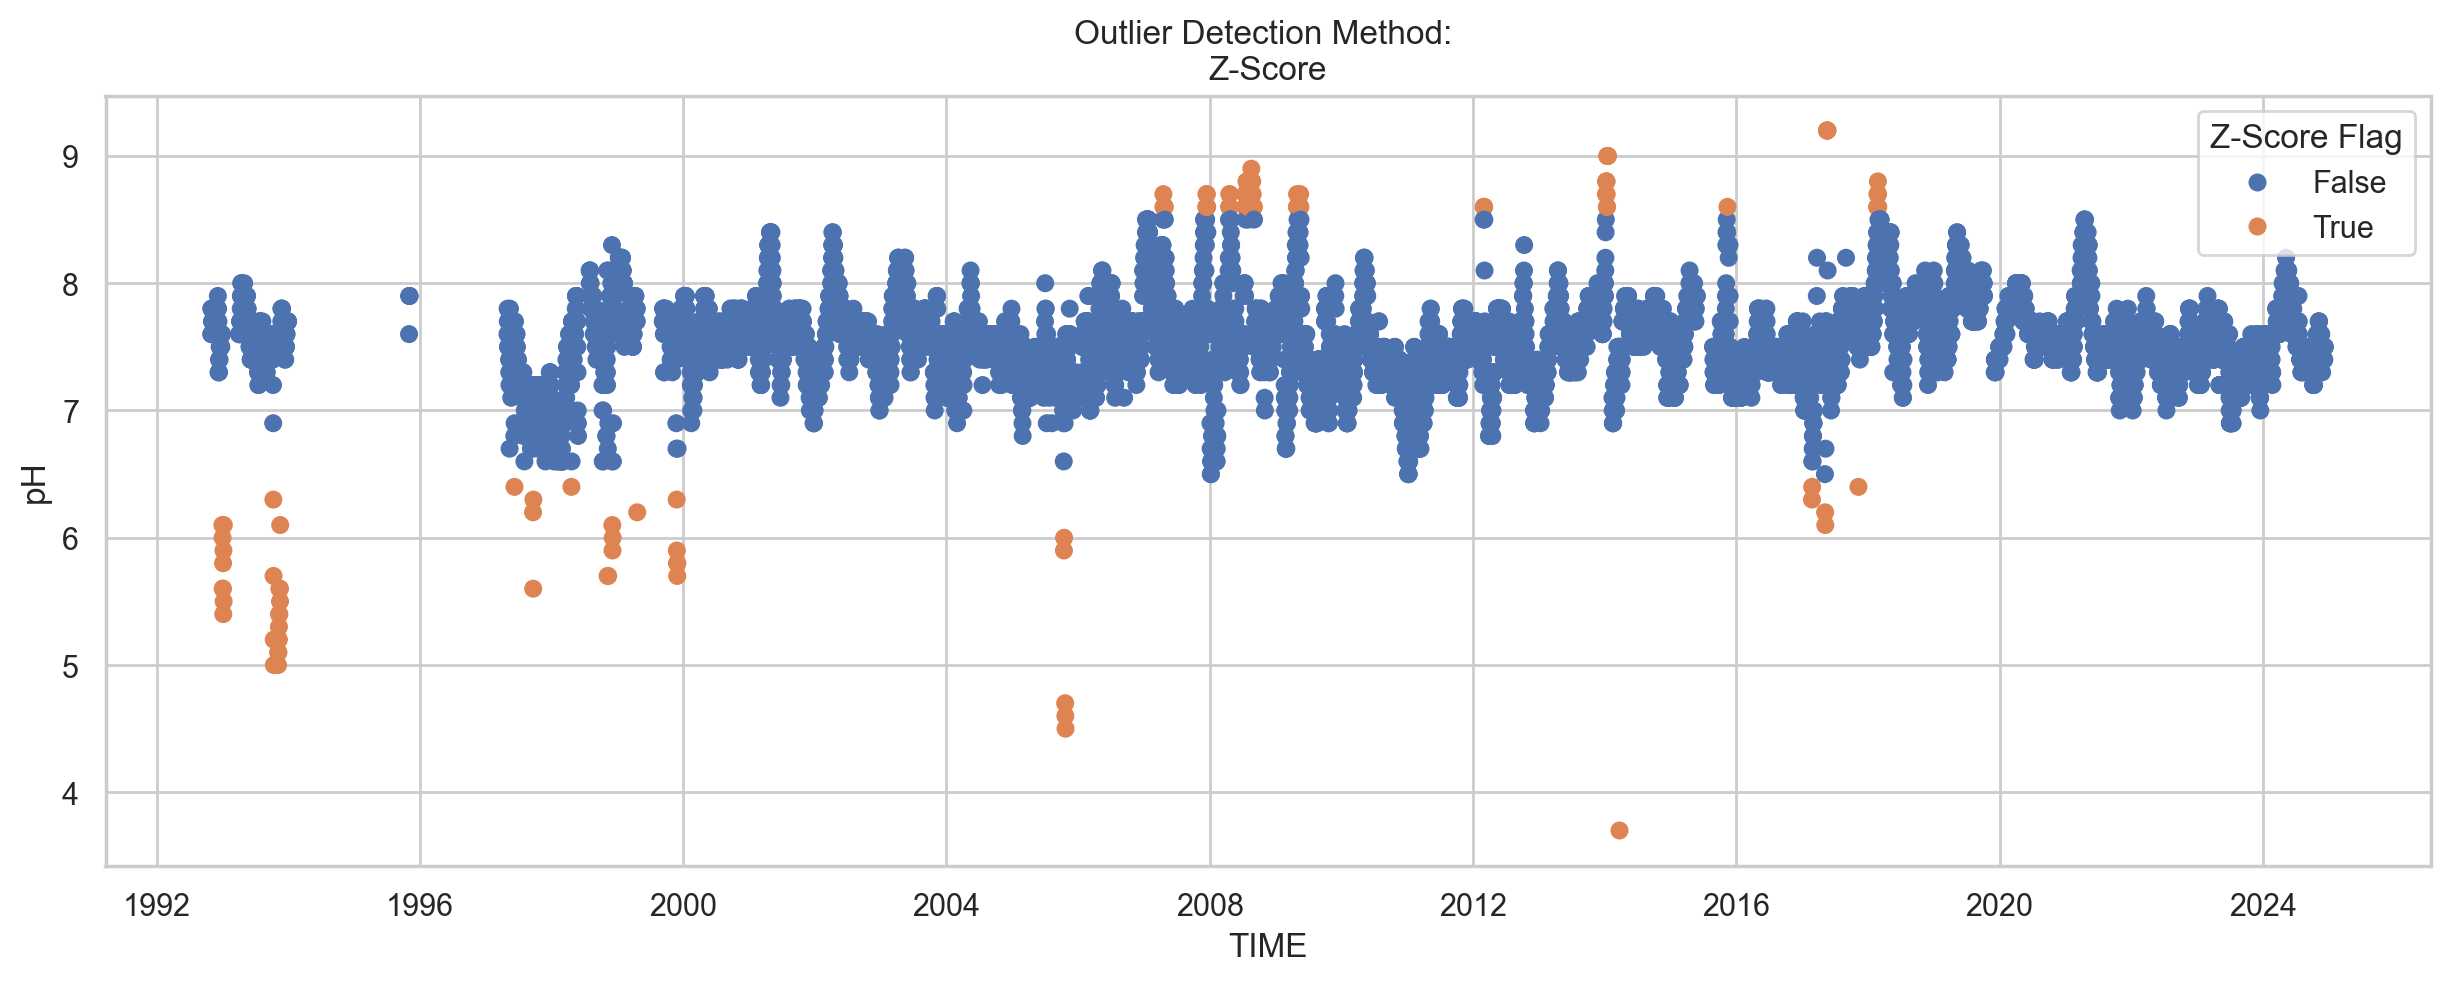

In [58]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_z_score, x='TIME', y='VALUE', hue='Z-Score Flag', edgecolor=None).set_title('Outlier Detection Method: \nZ-Score')
ax.set(ylabel='pH')
fig.savefig('zscore.png', dpi=300, transparent=True, bbox_inches='tight')

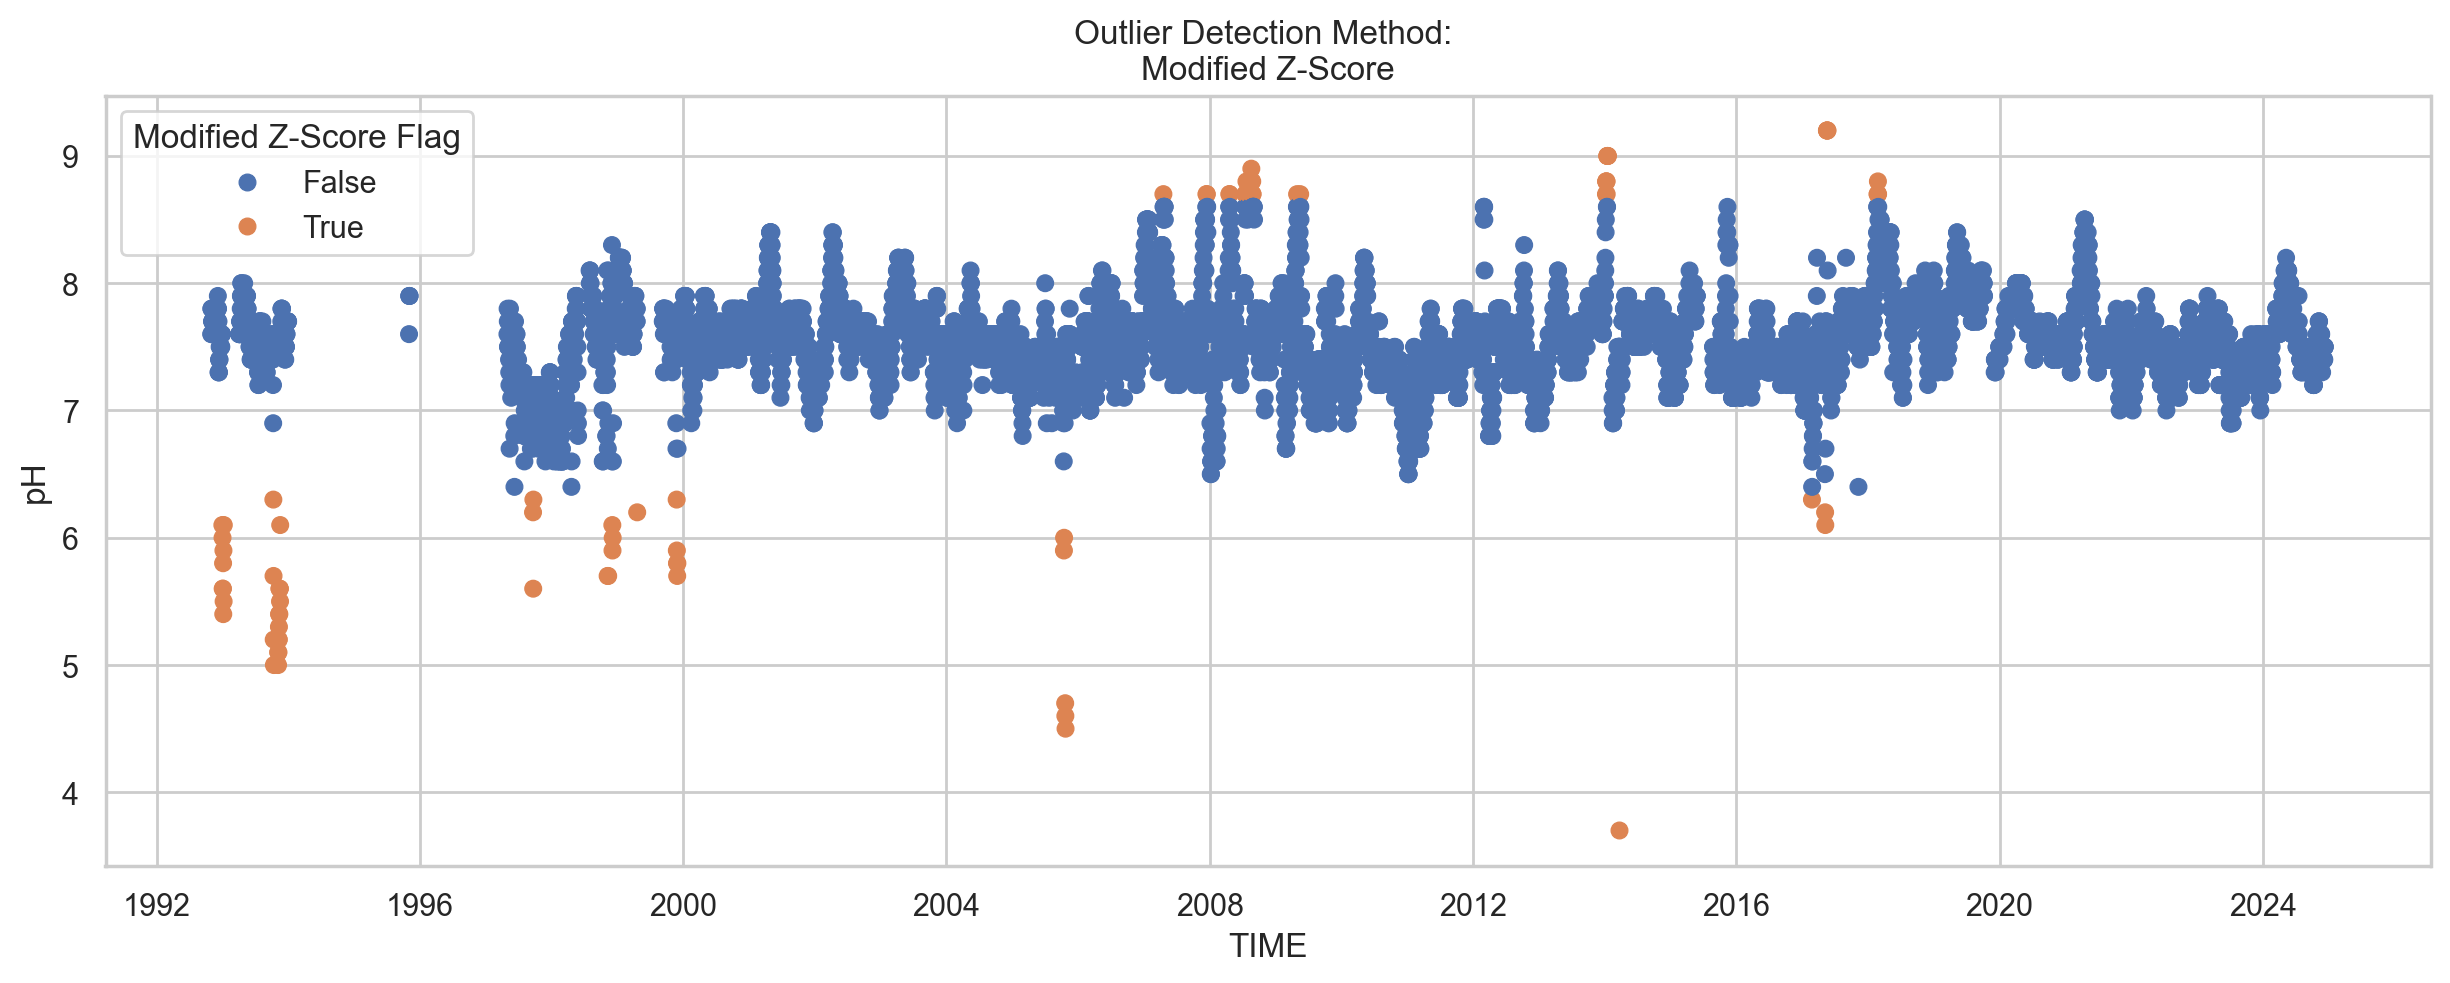

In [59]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_z_score, x='TIME', y='VALUE', hue='Modified Z-Score Flag', edgecolor=None).set_title('Outlier Detection Method: \nModified Z-Score')
ax.set(ylabel='pH')
fig.savefig('modifiedzscore.png', dpi=300, transparent=True, bbox_inches='tight')

### Tukey's Interquartile Range test

Tukey's Interquartile Range test calculates values that fall outside of 1.5 times the interquartile range between the first and third quartiles.

In [60]:
def tukey_iqr_test(time_series: pd.Series) -> pd.DataFrame:
    """
    Apply Tukey's IQR test to a time series.

    Parameters
    ----------
    time_series : pd.Series
        A pandas series with a datetime index.

    Returns
    -------
    pandas.DataFrame
        Outliers flagged as True or False.
    
    Examples
    --------
    >>> df_out = tukey_iqr_test(time_series)

    """
    if time_series.empty:
        raise ValueError('No input data.')
    c = stats.norm.ppf(3 / 4) - stats.norm.ppf(1 / 4)
    quantiles = time_series.quantile([0.25, 0.75])
    np.squeeze(np.diff(quantiles, axis=0) / c)
    iqr = quantiles[0.75] - quantiles[0.25]
    upper_limit = quantiles[0.75] + (iqr*1.5)
    lower_limit = quantiles[0.25] - (iqr*1.5)
    df['Tukey\'s IQR Flag']  = np.where(((time_series > upper_limit) | (time_series < lower_limit)), True, False)
    return df

In [61]:
df_tukey_iqr_score = tukey_iqr_test(time_series=df.VALUE)

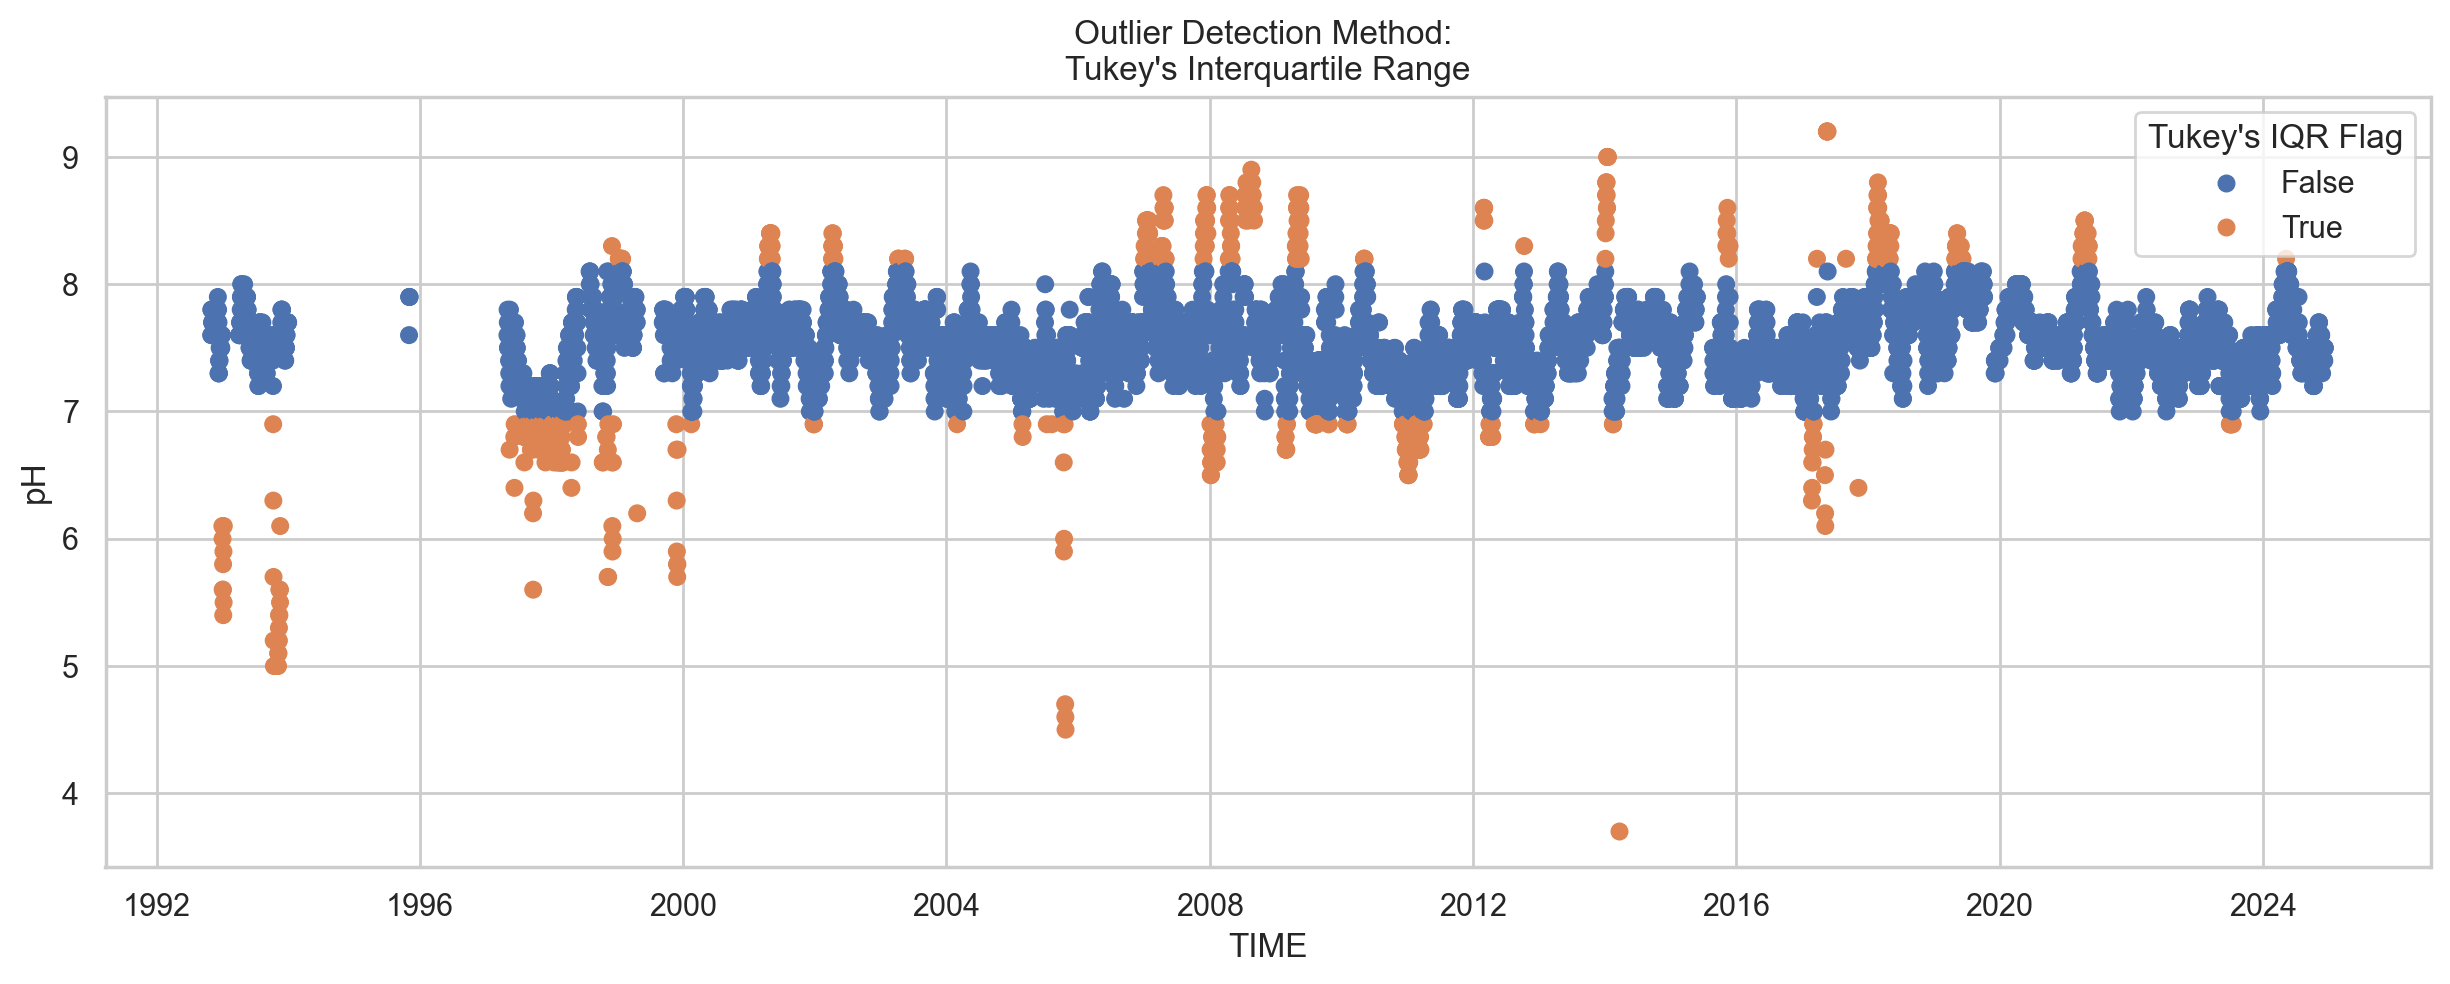

In [62]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_tukey_iqr_score, x='TIME', y='VALUE', hue='Tukey\'s IQR Flag', edgecolor=None).set_title('Outlier Detection Method: \nTukey\'s Interquartile Range')
ax.set(ylabel='pH')
fig.savefig('tukeyiqr.png', dpi=300, transparent=True, bbox_inches='tight')

### Spike Detection Test

The Spike Detection Test identifies a spike, defined as a value greater than the mean*factor of the adjacent values, in a time series.

In [63]:
def spike_detection_test(time_series: pd.Series, factor: float = 1.05) -> pd.DataFrame:
    """
    Identify a spike, defined as a value greater than the mean*factor of the adjacent values, in a time series.

    Parameters
    ----------
    time_series : pd.Series
        A pandas series with a datetime index.

    factor : float, optional
        The factor by which the mean of adjacent values is multiplied to determine a spike.

    Returns
    -------
    pandas.DataFrame
        Outliers flagged as True or False.
    
    Examples
    --------
    >>> df_out = spike_detection_test(time_series)

    """
    if time_series.empty:
        raise ValueError('No input data.')
    mean_adjacent = (time_series.shift(1) + time_series.shift(-1)) / 2
    df['Spike Flag'] = np.where((time_series > factor*mean_adjacent), True, False)
    return df

In [64]:
df_spike_detection = spike_detection_test(time_series=df.VALUE)

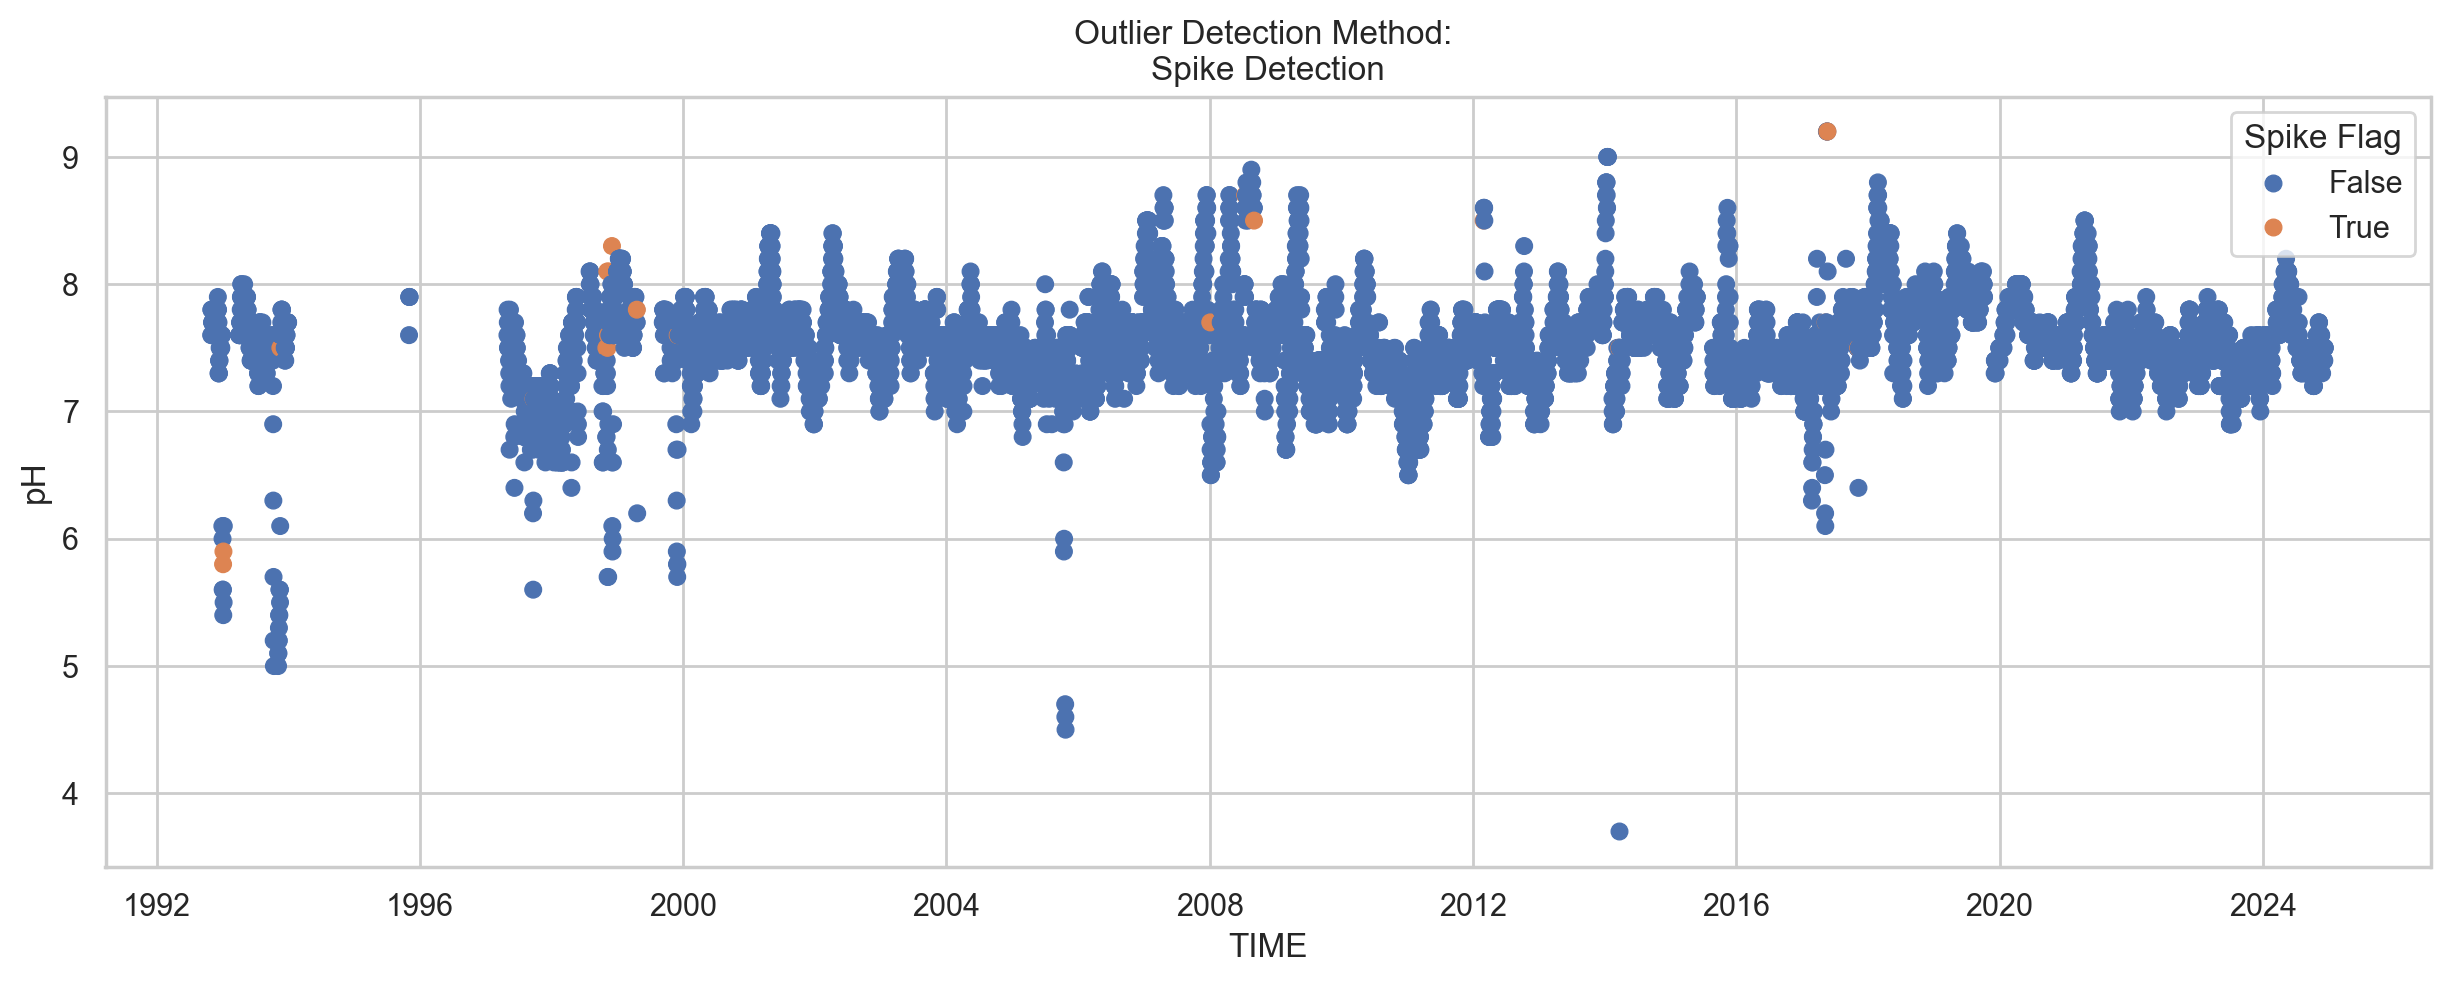

In [65]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_tukey_iqr_score, x='TIME', y='VALUE', hue='Spike Flag', edgecolor=None).set_title('Outlier Detection Method: \nSpike Detection')
ax.set(ylabel='pH')
fig.savefig('spike.png', dpi=300, transparent=True, bbox_inches='tight')

### Rate of Change Test

The Rate of Change Test compares the mean value of the previous N points to the specified point and determines if the difference between those two numbers exceeds a threshold.

In [66]:
def rate_of_change_test(time_series: pd.Series, threshold_value: int, previous_number_of_points: int = 5) -> pd.DataFrame:
    """
    The Rate of Change Test compares the mean value of the previous N points to any given point
    and determines if the difference between those two numbers exceeds a threshold.

    Parameters
    ----------
    time_series : pd.Series
        A pandas series with a datetime index.

    previous_number_of_points : int, optional
        The number of previous points to consider for the mean calculation. Default is 5.
    
    threshold_value : int
        The threshold value for the difference.

    Returns
    -------
    pandas.DataFrame
        Outliers flagged as True or False.
    
    Examples
    --------
    >>> df_out = spike_detection_test(time_series)

    """
    mean_previous = time_series.rolling(window=previous_number_of_points).mean()
    difference = time_series - mean_previous
    df['Rate of Change Flag'] = np.where(difference.abs() > threshold_value, True, False)
    return df

In [67]:
df_rate_of_change = rate_of_change_test(time_series=df.VALUE, threshold_value=0.5)

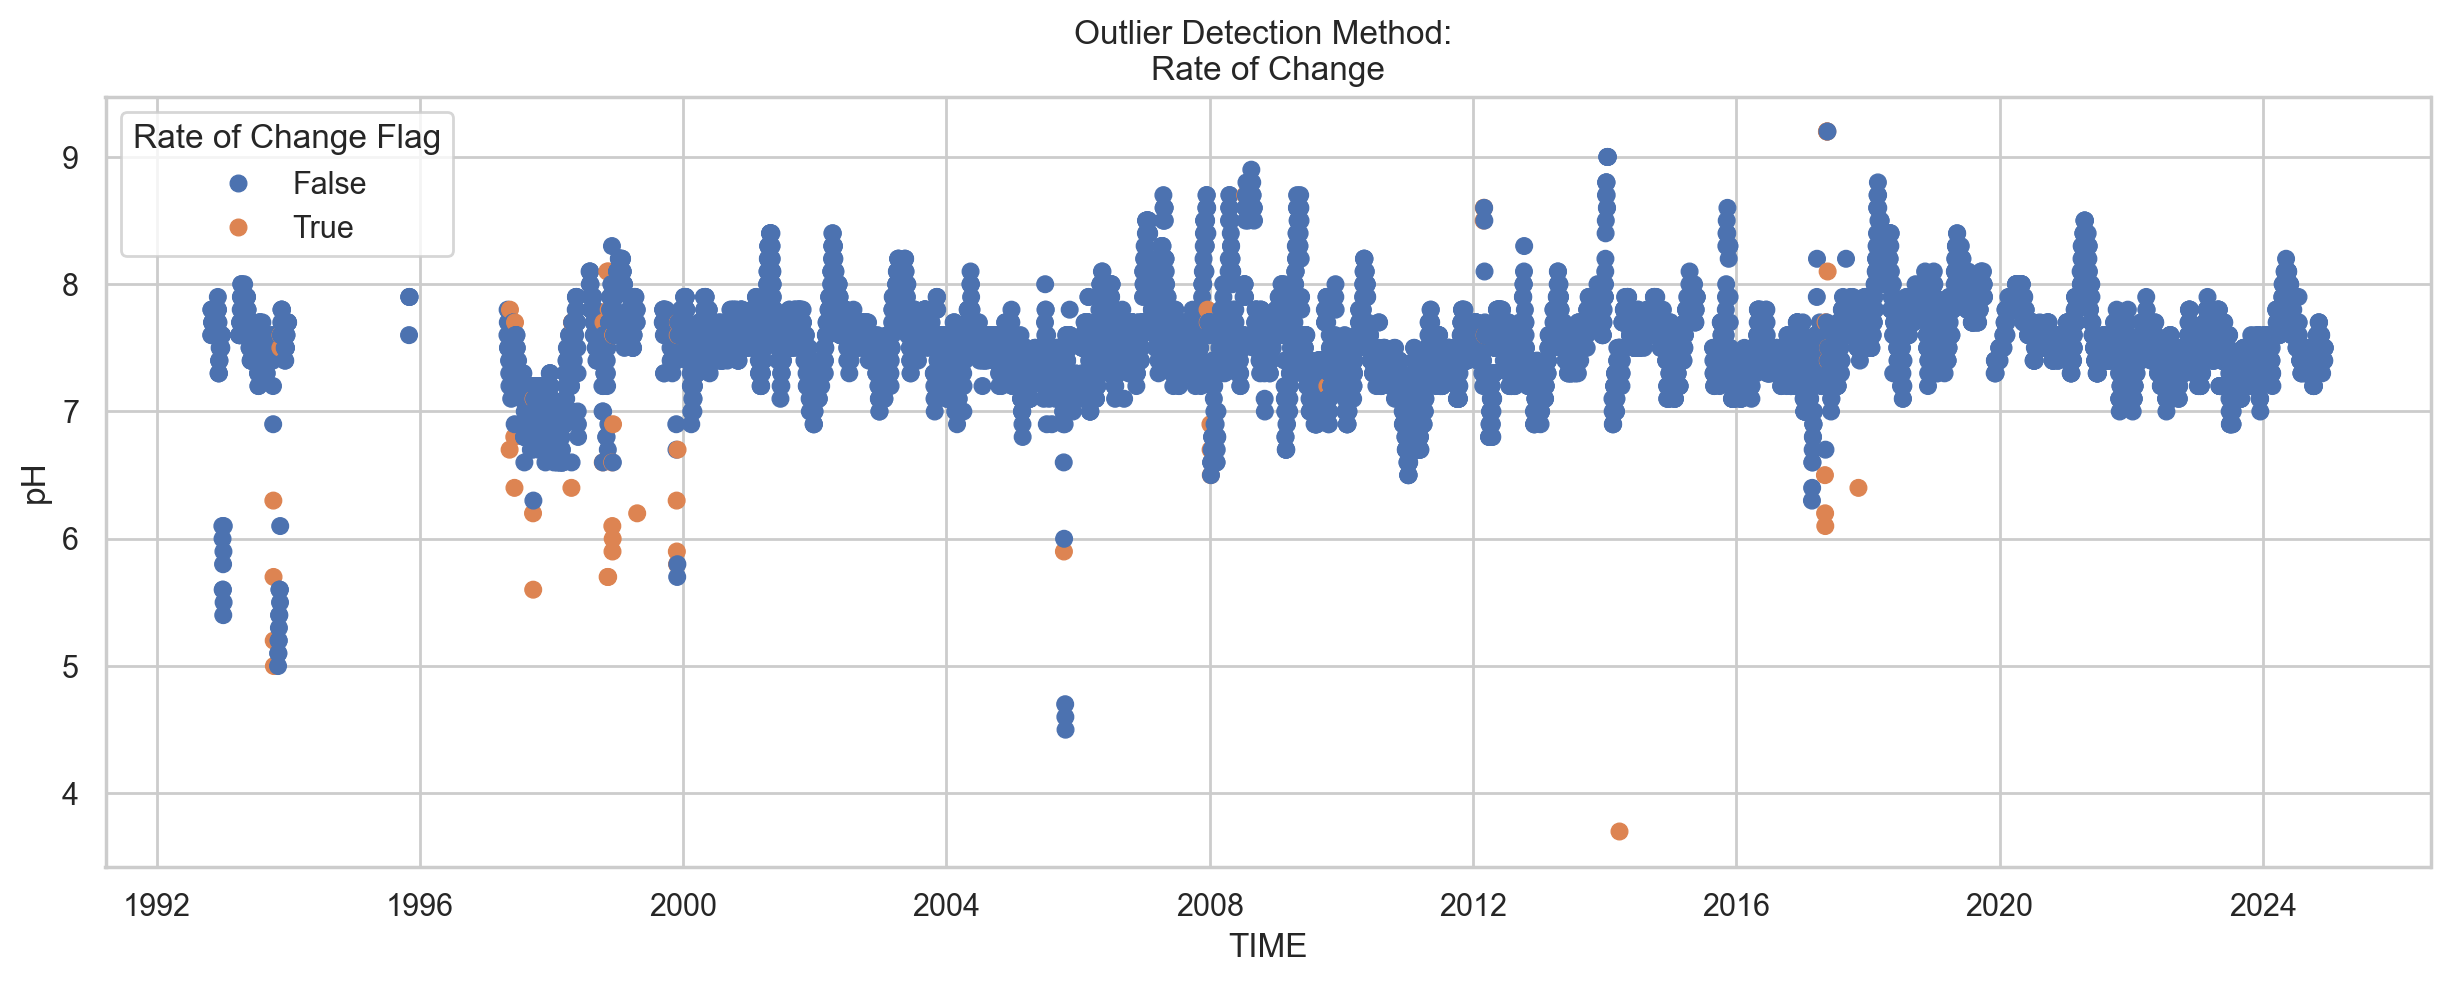

In [68]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
sns.scatterplot(df_rate_of_change, x='TIME', y='VALUE', hue='Rate of Change Flag', edgecolor=None).set_title('Outlier Detection Method: \nRate of Change')
ax.set(ylabel='pH')
fig.savefig('rateofchange.png', dpi=300, transparent=True, bbox_inches='tight')